# Part 4

In [14]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, ConcatDataset
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

## Data Preprocessing

In [15]:
def get_dataset_stats(data_path, batch_size=32):
   
    temp_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(root=data_path, transform=temp_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0

    print("Calculating statistics...")
    for data, _ in loader:
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5

    return mean.tolist(), std.tolist()


mean, std = get_dataset_stats("tiny-imagenet/train")
print(f"Mean: {mean}")
print(f"Std: {std}")


Calculating statistics...
Mean: [0.49222254753112793, 0.4660188555717468, 0.40885522961616516]
Std: [0.2633679211139679, 0.25188446044921875, 0.28283271193504333]


In [16]:
basic_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=mean, 
        std=std   
    )
])

In [17]:
test_dataset = datasets.ImageFolder(
    root="tiny-imagenet/test",
    transform=basic_transform
)
train_dataset_train = datasets.ImageFolder(
    root="tiny-imagenet/train",
    transform=basic_transform
)
train_dataset_val = datasets.ImageFolder(
    root="tiny-imagenet/val",
    transform=basic_transform
)
train_dataset = ConcatDataset([train_dataset_train, train_dataset_val])

In [18]:
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [19]:
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")

Train Dataset Size: 4000
Test Dataset Size: 1000


In [20]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)


torch.Size([8, 3, 64, 64])
torch.Size([8])


## Deep CNN model

In [21]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=10, use_bn=False):
        super().__init__()
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)

        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv7 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv8 = nn.Conv2d(128, 128, 3, padding=1)

        if use_bn:
            self.bn1 = nn.BatchNorm2d(32)
            self.bn2 = nn.BatchNorm2d(32)
            self.bn3 = nn.BatchNorm2d(64)
            self.bn4 = nn.BatchNorm2d(64)
            self.bn5 = nn.BatchNorm2d(128)
            self.bn6 = nn.BatchNorm2d(128)
            self.bn7 = nn.BatchNorm2d(128)
            self.bn8 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d((1,1))
        self.fc   = nn.Linear(128, num_classes)

        self._initialize_weights()

    def block(self, x, conv, bn=None):
        x = conv(x)
        if self.use_bn and bn is not None:
            x = bn(x)
        return F.relu(x)

    def forward(self, x):

        x = self.block(x, self.conv1, getattr(self, "bn1", None))
        x = self.block(x, self.conv2, getattr(self, "bn2", None))
        x = self.pool(x)

        x = self.block(x, self.conv3, getattr(self, "bn3", None))
        x = self.block(x, self.conv4, getattr(self, "bn4", None))
        x = self.pool(x)

        x = self.block(x, self.conv5, getattr(self, "bn5", None))
        x = self.block(x, self.conv6, getattr(self, "bn6", None))
        x = self.block(x, self.conv7, getattr(self, "bn7", None))
        x = self.block(x, self.conv8, getattr(self, "bn8", None))

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy


In [23]:
def train_one_epoch(model, loader, optimizer, criterion, max_stat_batches=500):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    mean_list = []
    var_list = []

    def hook_fn(module, input, output):
        if len(mean_list) < max_stat_batches:
            mean_list.append(output.mean(dim=[0,2,3]).mean().item())
            var_list.append(output.var(dim=[0,2,3]).mean().item())

    if model.use_bn:
     hook_handle = model.bn5.register_forward_hook(hook_fn)
    else:
     hook_handle = model.conv5.register_forward_hook(hook_fn)

    loop = tqdm(loader, leave=True)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100.*correct/total
        )

    hook_handle.remove()

    return (
        total_loss / len(loader),
        100. * correct / total,
        mean_list,
        var_list
    )


## Training without Batch Norm

In [24]:
model_no_bn = DeepCNN(use_bn=False).to(device)
optimizer_no_bn = torch.optim.Adam(model_no_bn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

EPOCHS = 20
train_losses_no_bn = []
train_accs_no_bn = []
test_losses_no_bn = []
test_accs_no_bn = []

t0 = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc, mean_no_bn, var_no_bn = train_one_epoch(
        model_no_bn,
        train_loader,
        optimizer_no_bn,
        criterion
    )

    te_loss, te_acc = evaluate_model(
        model_no_bn,
        test_loader,
        criterion
    )

    train_losses_no_bn.append(tr_loss)
    train_accs_no_bn.append(tr_acc)
    test_losses_no_bn.append(te_loss)
    test_accs_no_bn.append(te_acc)

    print(f"No BatchNorm Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}% | test_loss={te_loss:.4f} test_acc={te_acc:.4f}% | time={(time.time()-t0):.1f}s")
    t0 = time.time()


100%|██████████| 500/500 [00:41<00:00, 12.05it/s, acc=25.6, loss=1.62]


No BatchNorm Epoch 1/20 | train_loss=1.8706 train_acc=25.5500% | test_loss=1.6614 test_acc=34.4000% | time=44.6s


100%|██████████| 500/500 [00:40<00:00, 12.30it/s, acc=35.4, loss=1.36] 


No BatchNorm Epoch 2/20 | train_loss=1.6040 train_acc=35.3500% | test_loss=1.5903 test_acc=38.6000% | time=43.9s


100%|██████████| 500/500 [00:40<00:00, 12.39it/s, acc=38, loss=1.58]   


...

No BatchNorm Epoch 18/20 | train_loss=0.4267 train_acc=84.3250% | test_loss=1.3920 test_acc=62.8000% | time=45.0s


100%|██████████| 500/500 [00:41<00:00, 11.98it/s, acc=87.6, loss=0.693] 


No BatchNorm Epoch 19/20 | train_loss=0.3420 train_acc=87.6250% | test_loss=1.7775 test_acc=59.2000% | time=44.9s


100%|██████████| 500/500 [00:41<00:00, 11.92it/s, acc=88, loss=1.05]     


No BatchNorm Epoch 20/20 | train_loss=0.3289 train_acc=88.0000% | test_loss=1.6186 test_acc=61.3000% | time=45.2s


## Training with Batch Norm

In [25]:
model_bn = DeepCNN(use_bn=True).to(device)
optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=0.001)

EPOCHS = 20
train_losses_bn = []
train_accs_bn = []
test_losses_bn = []
test_accs_bn = []

t0 = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc, mean_bn, var_bn = train_one_epoch(
        model_bn,
        train_loader,
        optimizer_bn,
        criterion
    )

    te_loss, te_acc = evaluate_model(
        model_bn,
        test_loader,
        criterion
    )

    train_losses_bn.append(tr_loss)
    train_accs_bn.append(tr_acc)
    test_losses_bn.append(te_loss)
    test_accs_bn.append(te_acc)

    print(f"With BatchNorm Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}% | test_loss={te_loss:.4f} test_acc={te_acc:.4f}% | time={(time.time()-t0):.1f}s")
    t0 = time.time()


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:47<00:00, 10.49it/s, acc=34.8, loss=1.85]


With BatchNorm Epoch 1/20 | train_loss=1.7274 train_acc=34.8250% | test_loss=1.4499 test_acc=46.3000% | time=51.0s


100%|██████████| 500/500 [00:48<00:00, 10.29it/s, acc=44.4, loss=1.33] 


With BatchNorm Epoch 2/20 | train_loss=1.5114 train_acc=44.4250% | test_loss=1.2837 test_acc=51.2000% | time=52.0s


...

With BatchNorm Epoch 18/20 | train_loss=0.6802 train_acc=76.3750% | test_loss=0.9118 test_acc=69.4000% | time=51.0s


100%|██████████| 500/500 [00:47<00:00, 10.50it/s, acc=77.1, loss=0.634] 


With BatchNorm Epoch 19/20 | train_loss=0.6432 train_acc=77.0750% | test_loss=0.9022 test_acc=68.9000% | time=51.4s


100%|██████████| 500/500 [00:47<00:00, 10.50it/s, acc=78.7, loss=0.388] 


With BatchNorm Epoch 20/20 | train_loss=0.5871 train_acc=78.6750% | test_loss=0.9311 test_acc=69.7000% | time=51.3s


## Internal Covariate Shift Comparision

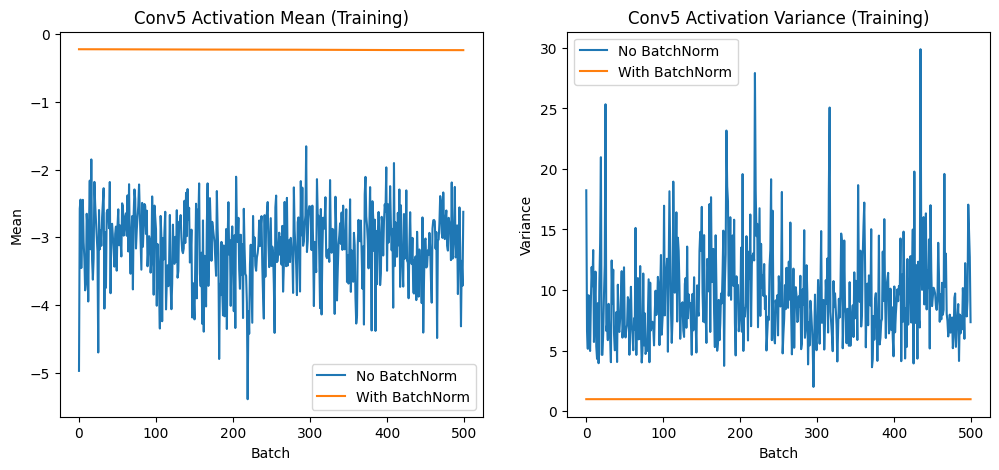

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(mean_no_bn, label="No BatchNorm")
plt.plot(mean_bn, label="With BatchNorm")
plt.title("Conv5 Activation Mean (Training)")
plt.xlabel("Batch")
plt.ylabel("Mean")
plt.legend()

plt.subplot(1,2,2)
plt.plot(var_no_bn, label="No BatchNorm")
plt.plot(var_bn, label="With BatchNorm")
plt.title("Conv5 Activation Variance (Training)")
plt.xlabel("Batch")
plt.ylabel("Variance")
plt.legend()

plt.show()


## Activation Distribution Visualisation

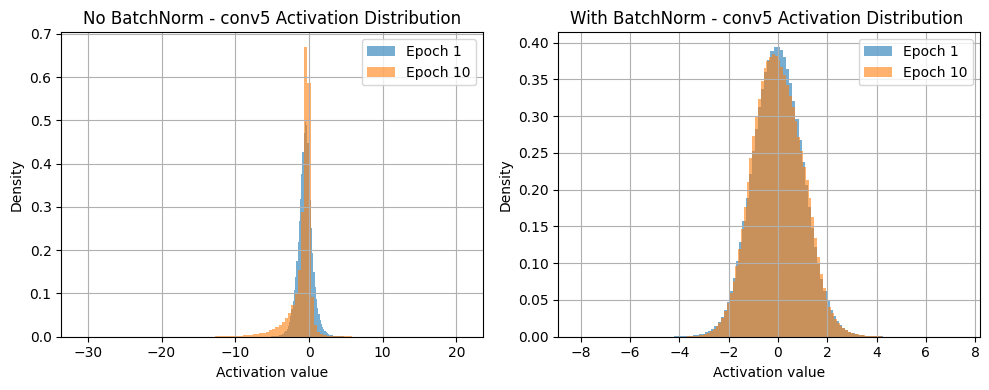

NoBN activations: epoch 1 count=13107200, epoch 10 count=13107200
WithBN activations: epoch 1 count=13107200, epoch 10 count=13107200


In [29]:
def collect_activations_during_training(model, loader, optimizer, criterion, epochs=10, target_epochs=(1,10), max_batches_per_epoch=50):
    device = next(model.parameters()).device
    activations = {e: np.array([]) for e in target_epochs}

    for epoch in range(1, epochs+1):
        act_batches = []

        def hook_fn(module, input, output):
            act_batches.append(output.detach().cpu().numpy().ravel())

        if model.use_bn:
         hook_handle = model.bn5.register_forward_hook(hook_fn)
        else:
         hook_handle = model.conv5.register_forward_hook(hook_fn)
        model.train()

        batch_count = 0
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_count += 1
            if batch_count >= max_batches_per_epoch:
                break

        hook_handle.remove()

        if epoch in target_epochs:
            if len(act_batches) > 0:
                activations[epoch] = np.concatenate(act_batches)
            else:
                activations[epoch] = np.array([])

    return activations

EPOCHS_SMALL = 10  
TARGET_EPOCHS = (1, EPOCHS_SMALL) 
MAX_BATCHES = 50  

model_nb_small = DeepCNN(use_bn=False).to(device)
opt_nb = torch.optim.Adam(model_nb_small.parameters(), lr=0.001)
print('Collecting activations while training No BatchNorm model (this may take a few minutes)')
acts_no_bn = collect_activations_during_training(model_nb_small, train_loader, opt_nb, criterion, epochs=EPOCHS_SMALL, target_epochs=TARGET_EPOCHS, max_batches_per_epoch=MAX_BATCHES)

model_bn_small = DeepCNN(use_bn=True).to(device)
opt_bn = torch.optim.Adam(model_bn_small.parameters(), lr=0.001)
print('Collecting activations while training With BatchNorm model (this may take a few minutes)')
acts_bn = collect_activations_during_training(model_bn_small, train_loader, opt_bn, criterion, epochs=EPOCHS_SMALL, target_epochs=TARGET_EPOCHS, max_batches_per_epoch=MAX_BATCHES)

bins = 120
alpha = 0.6

e1, e2 = TARGET_EPOCHS
a1 = acts_no_bn.get(e1, np.array([]))
a2 = acts_no_bn.get(e2, np.array([]))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
if a1.size > 0:
    plt.hist(a1, bins=bins, density=True, alpha=alpha, color='tab:blue', label=f'Epoch {e1}')
if a2.size > 0:
    plt.hist(a2, bins=bins, density=True, alpha=alpha, color='tab:orange', label=f'Epoch {e2}')
plt.title('No BatchNorm - conv5 Activation Distribution')
plt.xlabel('Activation value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

b1 = acts_bn.get(e1, np.array([]))
b2 = acts_bn.get(e2, np.array([]))
plt.subplot(1,2,2)
if b1.size > 0:
    plt.hist(b1, bins=bins, density=True, alpha=alpha, color='tab:blue', label=f'Epoch {e1}')
if b2.size > 0:
    plt.hist(b2, bins=bins, density=True, alpha=alpha, color='tab:orange', label=f'Epoch {e2}')
plt.title('With BatchNorm - conv5 Activation Distribution ')
plt.xlabel('Activation value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'NoBN activations: epoch {e1} count={a1.size}, epoch {e2} count={a2.size}')
print(f'WithBN activations: epoch {e1} count={b1.size}, epoch {e2} count={b2.size}')


In [30]:
test_loss_no_bn, test_acc_no_bn = evaluate_model(
    model_no_bn,
    test_loader,
    criterion
)
print(f"Test Results (No BN): Loss={test_loss_no_bn:.4f}, Accuracy={test_acc_no_bn:.2f}%")


Test Results (No BN): Loss=1.6186, Accuracy=61.30%


In [31]:
test_loss_bn, test_acc_bn = evaluate_model(
    model_bn,
    test_loader,
    criterion
)

print(f"Test Results (With BN): Loss={test_loss_bn:.4f}, Accuracy={test_acc_bn:.2f}%")

Test Results (With BN): Loss=0.9311, Accuracy=69.70%


## Data Augmentation

In [32]:
train_transform = transforms.Compose([
    transforms.RandomRotation(30), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std   
    )
])

In [33]:

train_dataset_train_aug = datasets.ImageFolder(
    root="tiny-imagenet/train",
    transform=train_transform
)
train_dataset_val_aug = datasets.ImageFolder(
    root="tiny-imagenet/val",
    transform=train_transform
)
train_dataset_aug = ConcatDataset([train_dataset_train, train_dataset_val, train_dataset_train_aug, train_dataset_val_aug])
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

print(f"Original size: {len(train_dataset_train) + len(train_dataset_val)}")
print(f"Expanded size (samples): {len(train_dataset_aug)}")


Original size: 4000
Expanded size (samples): 8000


In [34]:

test_loader_aug = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [35]:
print(f"Augmented Train Dataset Size (samples): {len(train_dataset_aug)}")
print(f"Augmented Test Dataset Size (samples): {len(test_loader_aug.dataset)}")

Augmented Train Dataset Size (samples): 8000
Augmented Test Dataset Size (samples): 1000


In [36]:
model_aug = DeepCNN(use_bn=True).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

EPOCHS = 20
train_losses_aug = []
train_accs_aug = []
test_losses_aug = []
test_accs_aug = []

t0 = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc, _, _ = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion
    )

    te_loss, te_acc = evaluate_model(
        model_aug,
        test_loader,
        criterion
    )

    train_losses_aug.append(tr_loss)
    train_accs_aug.append(tr_acc)
    test_losses_aug.append(te_loss)
    test_accs_aug.append(te_acc)

    print(f"With Augmentation Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}% | test_loss={te_loss:.4f} test_acc={te_acc:.4f}% | time={(time.time()-t0):.1f}s")
    t0 = time.time()


100%|██████████| 1000/1000 [01:24<00:00, 11.86it/s, acc=35, loss=1.36]  


With Augmentation Epoch 1/20 | train_loss=1.7286 train_acc=34.9750% | test_loss=1.4513 test_acc=42.9000% | time=87.4s


100%|██████████| 1000/1000 [01:23<00:00, 12.01it/s, acc=42.6, loss=1.43]


With Augmentation Epoch 2/20 | train_loss=1.5211 train_acc=42.6500% | test_loss=1.2668 test_acc=49.9000% | time=86.5s


100%|██████████| 1000/1000 [01:22<00:00, 12.12it/s, acc=47.4, loss=1.37]


...

With Augmentation Epoch 18/20 | train_loss=0.6145 train_acc=77.9250% | test_loss=0.8857 test_acc=71.5000% | time=89.6s


100%|██████████| 1000/1000 [01:26<00:00, 11.50it/s, acc=79.7, loss=0.174]


With Augmentation Epoch 19/20 | train_loss=0.5766 train_acc=79.7375% | test_loss=0.8759 test_acc=72.5000% | time=89.8s


100%|██████████| 1000/1000 [01:26<00:00, 11.49it/s, acc=80.4, loss=0.177]


With Augmentation Epoch 20/20 | train_loss=0.5584 train_acc=80.4000% | test_loss=1.0061 test_acc=71.0000% | time=89.9s


In [37]:
final_train_no_bn = train_accs_no_bn[-1] if ('train_accs_no_bn' in globals() and len(train_accs_no_bn) > 0) else None
final_test_no_bn  = test_accs_no_bn[-1]  if ('test_accs_no_bn'  in globals() and len(test_accs_no_bn)  > 0) else None

final_train_bn = train_accs_bn[-1] if ('train_accs_bn' in globals() and len(train_accs_bn) > 0) else None
final_test_bn  = test_accs_bn[-1]  if ('test_accs_bn'  in globals() and len(test_accs_bn)  > 0) else None

final_train_aug = train_accs_aug[-1] if ('train_accs_aug' in globals() and len(train_accs_aug) > 0) else None
final_test_aug  = test_accs_aug[-1]  if ('test_accs_aug'  in globals() and len(test_accs_aug)  > 0) else None

summary = pd.DataFrame({
    'Model': ['No BatchNorm', 'With BatchNorm', 'With Augmentation'],
    'Final Train Acc (%)': [final_train_no_bn, final_train_bn, final_train_aug],
    'Final Test Acc (%)':  [final_test_no_bn,  final_test_bn,  final_test_aug]
})

def fmt(v):
    return f"{v:.2f}" if (v is not None) else 'N/A'

print('Final Train/Test Accuracy Summary:')
print(summary.to_string(index=False, formatters={
    'Final Train Acc (%)': lambda v: fmt(v),
    'Final Test Acc (%)':  lambda v: fmt(v)
}))


Final Train/Test Accuracy Summary:
            Model Final Train Acc (%) Final Test Acc (%)
     No BatchNorm               88.00              61.30
   With BatchNorm               78.67              69.70
With Augmentation               80.40              71.00


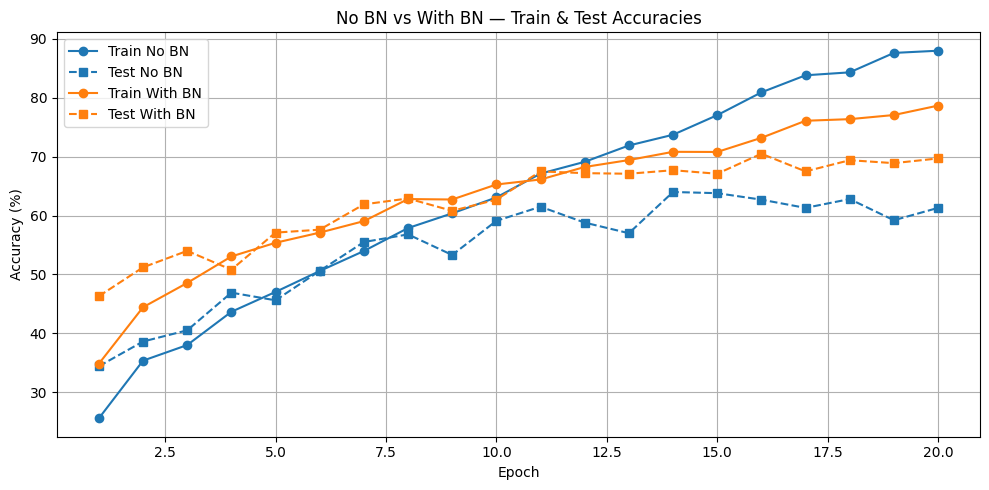

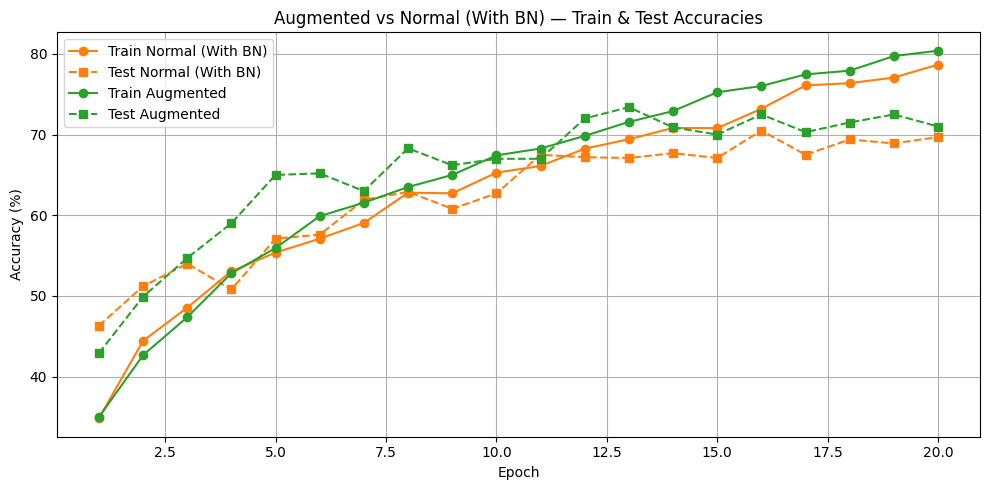

In [38]:
def _safe(name):
    return globals().get(name, []) or []

train_no = _safe('train_accs_no_bn')
test_no  = _safe('test_accs_no_bn')
train_bn = _safe('train_accs_bn')
test_bn  = _safe('test_accs_bn')
train_aug = _safe('train_accs_aug')
test_aug  = _safe('test_accs_aug')

if not any([train_no, test_no, train_bn, test_bn, train_aug, test_aug]):
    print('No accuracy data available to plot.')
else:
    plt.figure(figsize=(10,5))
    if train_no:
        plt.plot(range(1,len(train_no)+1), train_no, label='Train No BN', color='tab:blue', marker='o')
    if test_no:
        plt.plot(range(1,len(test_no)+1), test_no, label='Test No BN', color='tab:blue', linestyle='--', marker='s')
    if train_bn:
        plt.plot(range(1,len(train_bn)+1), train_bn, label='Train With BN', color='tab:orange', marker='o')
    if test_bn:
        plt.plot(range(1,len(test_bn)+1), test_bn, label='Test With BN', color='tab:orange', linestyle='--', marker='s')
    plt.title('No BN vs With BN — Train & Test Accuracies')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    if train_bn:
        plt.plot(range(1,len(train_bn)+1), train_bn, label='Train Normal (With BN)', color='tab:orange', marker='o')
    if test_bn:
        plt.plot(range(1,len(test_bn)+1), test_bn, label='Test Normal (With BN)', color='tab:orange', linestyle='--', marker='s')
    if train_aug:
        plt.plot(range(1,len(train_aug)+1), train_aug, label='Train Augmented', color='tab:green', marker='o')
    if test_aug:
        plt.plot(range(1,len(test_aug)+1), test_aug, label='Test Augmented', color='tab:green', linestyle='--', marker='s')
    plt.title('Augmented vs Normal (With BN) — Train & Test Accuracies')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Part 3

## Tiny Imagenet filter and convolution output visualisations

Using sample image from test_loader with label: 0


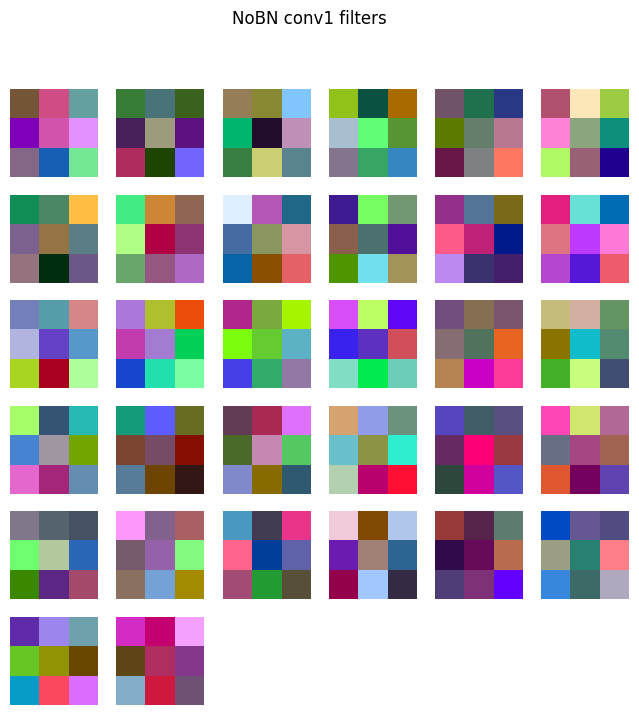

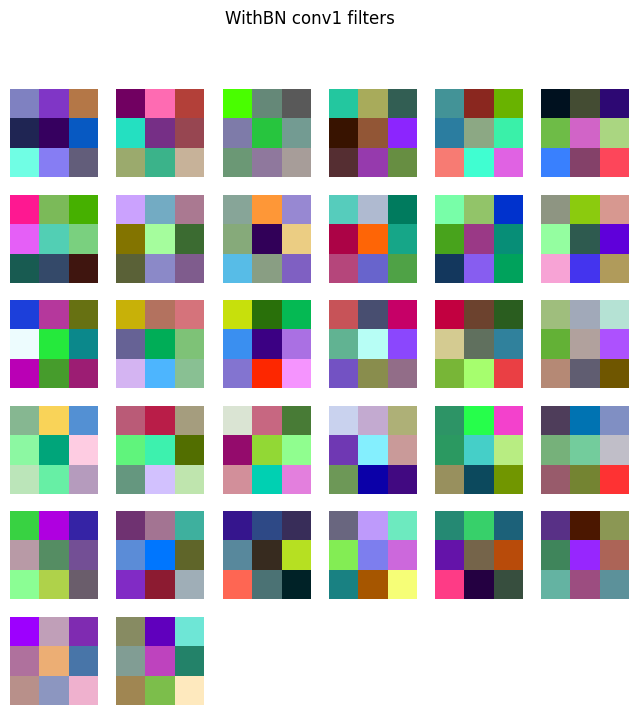

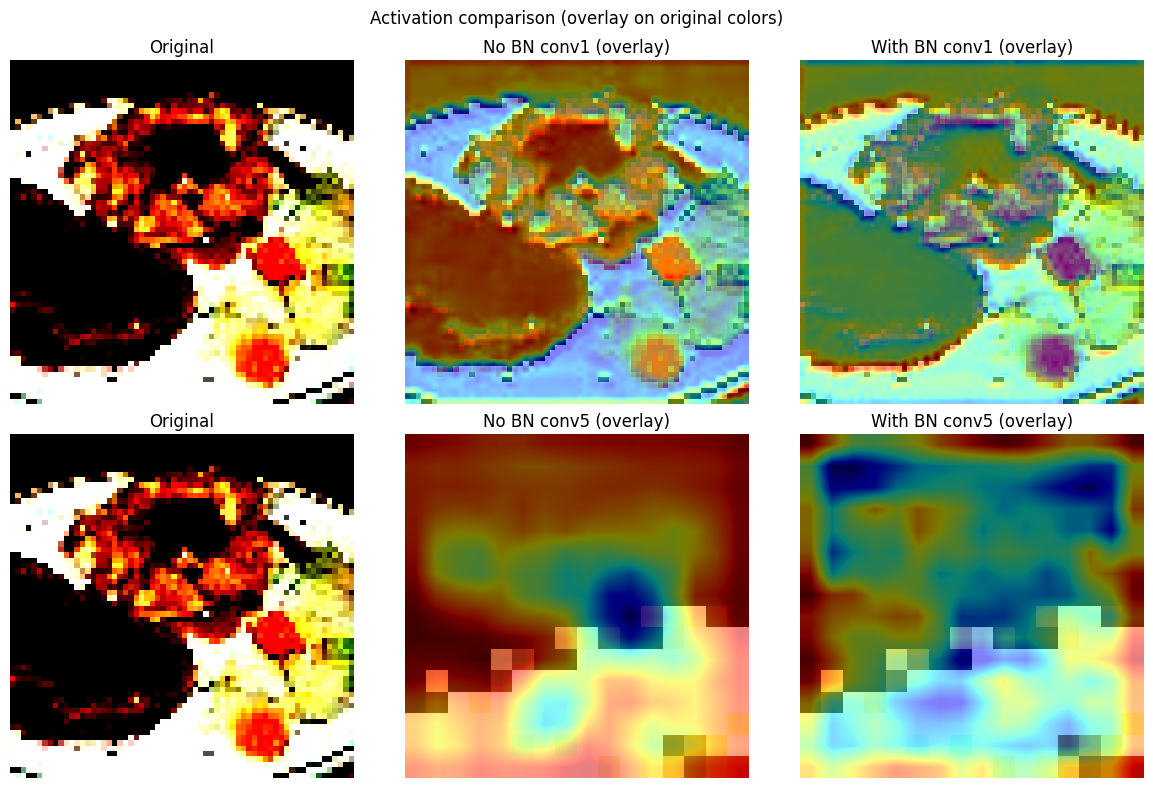

In [39]:
def plot_filters_rgb(model, layer='conv1', title='Filters'):
    weights = getattr(model, layer).weight.data.cpu()
    n = weights.shape[0]
    grid = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(8,8))
    for i in range(n):
        plt.subplot(grid, grid, i+1)
        w = weights[i]
        w_min, w_max = w.min(), w.max()
        w_norm = (w - w_min) / (w_max - w_min + 1e-6)
        plt.imshow(w_norm.permute(1,2,0))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


def get_activations_layers(model, image, layer_names):
    acts = {}
    handles = []
    for ln in layer_names:
        conv = getattr(model, ln)
        def make_hook(key):
            def hook(module, inp, out):
                acts[key] = out.detach().cpu()
            return hook
        h = conv.register_forward_hook(make_hook(ln))
        handles.append(h)
    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    for h in handles: h.remove()
    return acts


def plot_act_compare(image, model_a, model_b, layers=['conv1','conv5'], title_a='No BN', title_b='With BN', overlay_cmap='jet', alpha=0.5):
    acts_a = get_activations_layers(model_a, image, layers)
    acts_b = get_activations_layers(model_b, image, layers)
    num_layers = len(layers)
    fig, axes = plt.subplots(num_layers, 3, figsize=(12, 4 * num_layers))

    img = image.detach().cpu().permute(1,2,0).numpy()
    img = np.clip(img, 0.0, 1.0)

    axes_arr = axes
    axes_arr = np.array(axes_arr)
    if axes_arr.ndim == 1:
        axes_arr = axes_arr[np.newaxis, :]

    for i, ln in enumerate(layers):
        axes_arr[i,0].imshow(img)
        axes_arr[i,0].set_title('Original')
        axes_arr[i,0].axis('off')

        a_map = acts_a[ln][0].mean(0).numpy()
        a_map = (a_map - a_map.min()) / (a_map.max() - a_map.min() + 1e-6)
        axes_arr[i,1].imshow(img)
        axes_arr[i,1].imshow(a_map, cmap=overlay_cmap, alpha=alpha, interpolation='bilinear')
        axes_arr[i,1].set_title(f'{title_a} {ln} (overlay)')
        axes_arr[i,1].axis('off')

        b_map = acts_b[ln][0].mean(0).numpy()
        b_map = (b_map - b_map.min()) / (b_map.max() - b_map.min() + 1e-6)
        axes_arr[i,2].imshow(img)
        axes_arr[i,2].imshow(b_map, cmap=overlay_cmap, alpha=alpha, interpolation='bilinear')
        axes_arr[i,2].set_title(f'{title_b} {ln} (overlay)')
        axes_arr[i,2].axis('off')

    plt.suptitle('Activation comparison (overlay on original colors)')
    plt.tight_layout()
    plt.show()

try:
    images, labels = next(iter(test_loader))
    sample_img = images[0]
    print('Using sample image from test_loader with label:', int(labels[0]))
    if 'model_no_bn' in globals() and 'model_bn' in globals():
        plot_filters_rgb(model_no_bn, layer='conv1', title='NoBN conv1 filters')
        plot_filters_rgb(model_bn, layer='conv1', title='WithBN conv1 filters')
        plot_act_compare(sample_img, model_no_bn, model_bn, layers=['conv1','conv5'], title_a='No BN', title_b='With BN')
    else:
        print('Models model_no_bn and/or model_bn not found in globals. Run training cells first.')
except Exception as e:
    print('Could not get sample image from test_loader:', e)
